In [52]:
pip install docx

Note: you may need to restart the kernel to use updated packages.


In [53]:
pip install python-docx pandas

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from docx import Document
import os
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

In [55]:
data = []
base = r"C:\Users\Admin\Downloads\P658_DATASET\Resumes"
for item in os.listdir(base):
    item_path = os.path.join(base, item)
    if os.path.isdir(item_path):
        for file in os.listdir(item_path):
            if file.endswith(".docx"):
                file_path = os.path.join(item_path, file)
                doc = Document(file_path)
                text = ""
                for p in doc.paragraphs:
                    text += p.text
                data.append([text, item])
    else:
        if item.endswith(".docx"):
            file_path = os.path.join(base, item)
            doc = Document(file_path)
            text = ""
            for p in doc.paragraphs:
                text += p.text
            if "react" in item.lower():
                label = "React Developer"
            else:
                label = "Unknown"
            data.append([text, label])
df = pd.DataFrame(data, columns=["text", "category"])
print(df.head())

                                                text            category
0  Name: Ravali P                                ...             Unknown
1    SUSOVAN  BAG   Seeking  a  challenging  posi...             Unknown
2    Anubhav Kumar Singh\t\t  To work in a global...  Peoplesoft resumes
3  MuraliExperience Summary I have 6 years of exp...  Peoplesoft resumes
4  PROFILE SUMMARYI have overall 6.8 years’ exper...  Peoplesoft resumes


In [56]:
df.tail()

,text,category
47,Rahul (Techno Functional Consultant) Profess...,workday resumes
48,Ramesh A\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t...,workday resumes
49,Seeking suitable positions in Workday HCM as ...,workday resumes
50,WORKDAY | HCM | FCMName \t\t: Kumar S.SRole \t...,workday resumes
51,...,workday resumes


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      52 non-null     object
 1   category  52 non-null     object
dtypes: object(2)
memory usage: 964.0+ bytes


In [58]:
df.shape

(52, 2)

In [59]:
df.describe()

,text,category
count,52,52
unique,50,5
top,MAREEDU LOKESH BABUPROFESSIONAL OVERVIEW Aro...,React Developer
freq,2,18


In [60]:
df.columns

Index(['text', 'category'], dtype='object')

In [61]:
df.isnull().sum()

text        0
category    0
dtype: int64

In [62]:
df.duplicated().sum()

np.int64(2)

In [63]:
df["category"].value_counts()

category
React Developer                    18
workday resumes                    11
SQL Developer Lightning insight    11
Peoplesoft resumes                 10
Unknown                             2
Name: count, dtype: int64

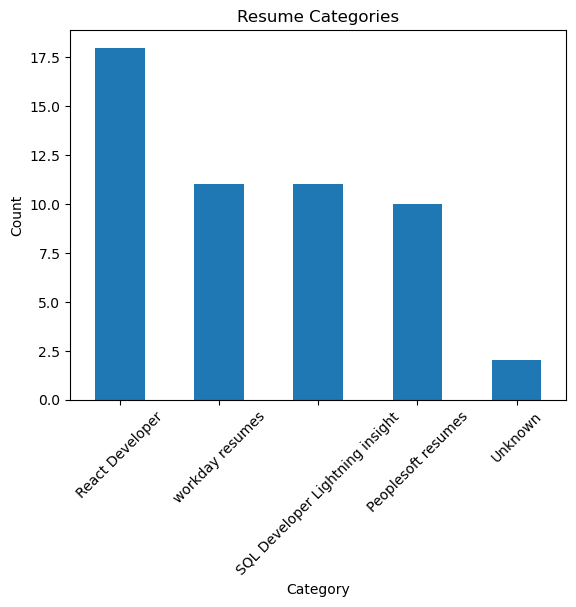

In [64]:

df["category"].value_counts().plot(kind='bar')
plt.title("Resume Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [65]:

def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text)   # remove special characters
    text = text.lower()                     # convert to lowercase
    text = text.split()                     # tokenize
    text = " ".join(text)                   # join back
    return text

In [66]:
df["cleaned"] = df["text"].apply(clean_text)
df.head()

,text,category,cleaned
0,Name: Ravali P ...,Unknown,name ravali p curriculum vitae specialization ...
1,SUSOVAN BAG Seeking a challenging posi...,Unknown,susovan bag seeking a challenging position in ...
2,Anubhav Kumar Singh\t\t To work in a global...,Peoplesoft resumes,anubhav kumar singh to work in a globally comp...
3,MuraliExperience Summary I have 6 years of exp...,Peoplesoft resumes,muraliexperience summary i have years of exper...
4,PROFILE SUMMARYI have overall 6.8 years’ exper...,Peoplesoft resumes,profile summaryi have overall years experience...


In [67]:
X = df["cleaned"]
y = df["category"]

In [68]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)
)
X = tfidf.fit_transform(X)

In [69]:

le = LabelEncoder()
y = le.fit_transform(y)

In [70]:
import joblib
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [71]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [72]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC()
}

In [73]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    print(f"{name} Accuracy: {acc}")

Naive Bayes Accuracy: 1.0
Logistic Regression Accuracy: 0.9090909090909091
SVM Accuracy: 1.0


In [74]:
results

{'Naive Bayes': 1.0, 'Logistic Regression': 0.9090909090909091, 'SVM': 1.0}

In [75]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Best Model: Naive Bayes


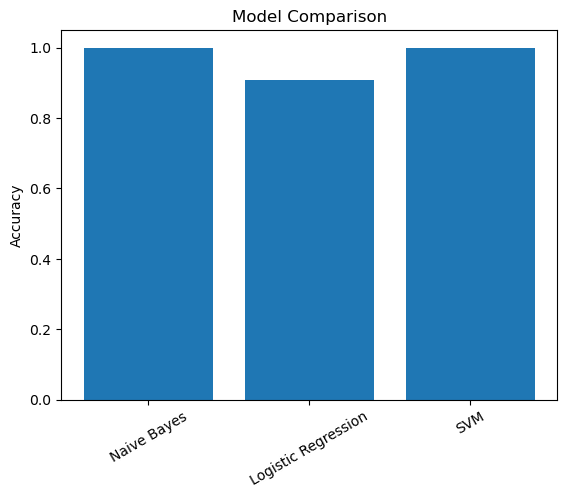

In [76]:
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [77]:
best_model = models[best_model_name]

import joblib
joblib.dump(best_model, "model.pkl")
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']